# 03 Experiment: input normalisation

**Question.** Which coordinate system should every model use?

| condition | input channels per joint | what the model can see |
|---|---|---|
| `pixel` | x, y, confidence, bone dx, bone dy (5) | pose, court position, player size |
| `body` | same 5, hip centred and in body height units | pose only |
| `body_court` | the 5 `body` channels + hip position in frame units (7) | pose and court position, not size |

The data audit showed that court position, player size and clip length alone reach about 55% top 1 on the test
set, partly through a legitimate cue (where shots are played from) and partly through the different camera
setup of the drill sessions. This experiment measures how much each cue contributes once the model also sees
the motion.

**Fixed across conditions.** ST-GCN (Yan et al., 2018) with the paper configuration (9 stages, 64/128/256
channels, temporal stride 2 at stages 4 and 7), repaired 30 frame keypoints, advanced augmentation, class
balanced sampling, SGD (lr 0.01, momentum 0.9, weight decay 1e-3), StepLR (step 10, gamma 0.1), batch 16,
up to 60 epochs with patience 20, checkpoint chosen on validation top 1. Three seeds per condition.

Each run is its own ClearML task in `BadmintonPoseAnalysis/experiments/normalisation`; the summary at the end
is a separate task in the same subproject.

In [1]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from clearml import Task

REPO = os.environ.get("BADMINTON_REPO", "/workspace/badminton-honours-project")
DATA = os.environ.get("BADMINTON_DATA", "/workspace/data")
sys.path.insert(0, REPO)
import dataset as ds
import training as tr

from mmaction.utils import register_all_modules
from mmaction.registry import MODELS
register_all_modules()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__, device, torch.cuda.get_device_name(0) if device.type == "cuda" else "")

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.spines.top": False, "axes.spines.right": False})

2.1.0+cu118 cuda NVIDIA GeForce RTX 4090


In [2]:
PROJECT = "BadmintonPoseAnalysis/experiments/normalisation"
KEYPOINTS = f"{DATA}/keypoints_interp"
OUT = os.environ.get("BADMINTON_OUTPUTS", "/workspace/outputs") + "/experiments/normalisation"
os.makedirs(OUT, exist_ok=True)

SEEDS = [42, 123, 7]
CONDITIONS = {
    "pixel": {"normalisation": "pixel", "court": False},
    "body": {"normalisation": "body", "court": False},
    "body_court": {"normalisation": "body", "court": True},
}
RECIPE = {
    "model": "ST-GCN", "augmentation": "advanced", "min_native_frames": 5, "target_per_class": 500,
    "batch_size": 16, "lr": 0.01, "momentum": 0.9, "weight_decay": 1e-3, "step_size": 10, "gamma": 0.1,
    "num_epochs": 60, "patience": 20, "select_metric": "top1", "label_smoothing": 0.0,
}

# references for the summary
LI_ET_AL_STGCN = {"top1": 0.7441, "top5": 0.9376, "mca": 0.6144}
NO_MOTION_PROBE = {"top1": 0.549, "mca": 0.429}   # 01_data_audit section 7, position + size + length

In [3]:
manifest = ds.load_filtered_manifest(f"{DATA}/split_manifest.csv", f"{DATA}/extraction_log.csv",
                                     f"{DATA}/keypoints_interp_log.csv", RECIPE["min_native_frames"])
class_names = sorted(manifest["class_name"].unique())
class_to_id = {c: i for i, c in enumerate(class_names)}
split_hash = open(f"{DATA}/split_manifest.sha256").read().split()[0]

manual review: dropped 4 clips
short clip rule: dropped 4 train clips with fewer than 5 real frames
7810 clips remain (train 6247, test 782, val 781)


## Model and input

The backbone is mmaction2's `STGCN` with the configuration above and the COCO graph, followed by `GCNHead`.
The input is shaped (N, clips, persons, T, V, C) = (N, 1, 1, 30, 17, C). For `body_court` the two court
channels are the same for every joint of a frame.

In [4]:
def build_stgcn(in_channels, num_classes=len(class_names)):
    cfg = dict(
        type="RecognizerGCN",
        backbone=dict(type="STGCN", graph_cfg=dict(layout="coco", mode="stgcn_spatial"),
                      in_channels=in_channels, base_channels=64, ch_ratio=2,
                      num_stages=9, inflate_stages=[4, 7], down_stages=[4, 7]),
        cls_head=dict(type="GCNHead", num_classes=num_classes, in_channels=256,
                      loss_cls=dict(type="CrossEntropyLoss")),
    )
    return MODELS.build(cfg)


def make_forward(use_court):
    def forward(model, batch, device):
        parts = [batch["keypoints"], batch["bone"]]
        if use_court:
            parts.append(batch["court"][:, :, None, :].expand(-1, -1, ds.NUM_JOINTS, -1))
        x = torch.cat(parts, dim=-1).float().to(device, non_blocking=True)
        return model(x[:, None, None], mode="tensor", stage="head")
    return forward


def in_channels(cond):
    return 7 if CONDITIONS[cond]["court"] else 5

## Smoke test

Run this cell on its own first. For each condition it builds the loaders and model, runs one training batch
forward and backward, checks every parameter gets a gradient, and evaluates the untrained model on validation.

In [5]:
for cond, spec in CONDITIONS.items():
    tr.seed_everything(0)
    loaders = tr.build_loaders(manifest, KEYPOINTS, class_to_id, RECIPE["augmentation"], spec["normalisation"],
                               seed=0, batch_size=RECIPE["batch_size"], num_workers=2)
    model = build_stgcn(in_channels(cond)).to(device)
    forward = make_forward(spec["court"])
    batch = next(iter(loaders["train"]))
    logits = forward(model, batch, device)
    assert logits.shape == (RECIPE["batch_size"], len(class_names)), logits.shape
    nn.CrossEntropyLoss()(logits, batch["label"].to(device)).backward()
    missing = [n for n, p in model.named_parameters() if p.requires_grad and p.grad is None]
    assert not missing, missing
    val = tr.evaluate(model, loaders["val"], forward, device)
    xy = batch["keypoints"][..., :2]
    print(f"{cond:11s} channels {in_channels(cond)}  params {sum(p.numel() for p in model.parameters()):,}  "
          f"xy range [{xy.min():.2f}, {xy.max():.2f}]  untrained val top1 {val['top1']:.3f}")
    del model, loaders
print("smoke test passed")

pixel       channels 5  params 3,027,831  xy range [218.07, 954.74]  untrained val top1 0.014
body        channels 5  params 3,027,831  xy range [-1.54, 1.07]  untrained val top1 0.120
body_court  channels 7  params 3,028,283  xy range [-1.54, 1.07]  untrained val top1 0.014
smoke test passed


## Runs

Nine runs (three conditions, three seeds). Results are appended to `results.csv` after every run and
finished runs are skipped, so the cell can be re-run after an interruption.

In [6]:
results_path = f"{OUT}/results.csv"
done = pd.read_csv(results_path) if os.path.exists(results_path) else pd.DataFrame(columns=["condition", "seed"])

for cond, spec in CONDITIONS.items():
    for seed in SEEDS:
        if ((done["condition"] == cond) & (done["seed"] == seed)).any():
            print(f"skip {cond} seed {seed}, already done")
            continue
        run_name = f"stgcn_{cond}_s{seed}"
        print(f"\n=== {run_name} ===")
        tr.seed_everything(seed)

        task = Task.init(project_name=PROJECT, task_name=run_name, task_type=Task.TaskTypes.training,
                         tags=["normalisation", cond, "stgcn", f"seed{seed}"], reuse_last_task_id=False,
                         auto_connect_frameworks={"matplotlib": False, "pytorch": False})
        task.connect({**RECIPE, **spec, "condition": cond, "seed": seed, "in_channels": in_channels(cond),
                      "keypoints": KEYPOINTS, "split_sha256": split_hash})

        loaders = tr.build_loaders(manifest, KEYPOINTS, class_to_id, RECIPE["augmentation"], spec["normalisation"],
                                   seed=seed, batch_size=RECIPE["batch_size"], target_per_class=RECIPE["target_per_class"])
        model = build_stgcn(in_channels(cond)).to(device)
        forward = make_forward(spec["court"])
        optimizer = torch.optim.SGD(model.parameters(), lr=RECIPE["lr"], momentum=RECIPE["momentum"],
                                    weight_decay=RECIPE["weight_decay"])
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=RECIPE["step_size"], gamma=RECIPE["gamma"])
        criterion = nn.CrossEntropyLoss(label_smoothing=RECIPE["label_smoothing"])

        _, history, best_epoch = tr.train_model(model, forward, loaders, optimizer, scheduler, criterion, device,
                                                task.get_logger(), num_epochs=RECIPE["num_epochs"],
                                                patience=RECIPE["patience"], select_metric=RECIPE["select_metric"])
        metrics = tr.report_run(task, model, forward, loaders, class_names, device, history, best_epoch,
                                out_dir=f"{OUT}/{run_name}", run_name=run_name,
                                extra={"condition": cond, "seed": seed}, show=False)
        task.close()

        done = pd.concat([done, pd.DataFrame([metrics])], ignore_index=True)
        done.to_csv(results_path, index=False)
        del model, loaders
        torch.cuda.empty_cache()


=== stgcn_pixel_s42 ===
ClearML Task: created new task id=0fe2c69904fb45dd864a82a5e0360d81
2026-09-28 09:15:50,153 - clearml.Repository Detection - WARNING - Failed accessing the jupyter server(s): []
ClearML results page: https://app.clear.ml/projects/31a1a8ee4ca742719e7d80b0bb693648/tasks/0fe2c69904fb45dd864a82a5e0360d81/output/log
epoch   0  loss 2.086  train 0.553  val 0.560 (mca 0.475)  *
epoch   1  loss 1.538  train 0.588  val 0.590 (mca 0.510)  *
epoch   3  loss 1.189  train 0.632  val 0.607 (mca 0.600)  *
epoch   4  loss 1.097  train 0.705  val 0.657 (mca 0.601)  *
epoch   5  loss 1.033  train 0.746  val 0.686 (mca 0.598)  *
epoch  10  loss 0.546  train 0.856  val 0.723 (mca 0.658)  *
epoch  11  loss 0.464  train 0.879  val 0.727 (mca 0.644)  *
epoch  14  loss 0.371  train 0.907  val 0.731 (mca 0.649)  *
epoch  15  loss 0.339  train 0.927  val 0.729 (mca 0.636)
epoch  20  loss 0.225  train 0.966  val 0.714 (mca 0.634)
epoch  25  loss 0.195  train 0.977  val 0.725 (mca 0.631)
e

███████████████████████████████ 100% | 11.66/11.66 MB [00:02<00:00,  4.53MB/s]: 



=== stgcn_pixel_s123 ===


Failed accessing the jupyter server(s): []


ClearML Task: created new task id=0e798ab1c85e4384b539fc6542678261
ClearML results page: https://app.clear.ml/projects/31a1a8ee4ca742719e7d80b0bb693648/tasks/0e798ab1c85e4384b539fc6542678261/output/log
epoch   0  loss 2.056  train 0.558  val 0.562 (mca 0.458)  *
epoch   1  loss 1.505  train 0.609  val 0.592 (mca 0.508)  *
epoch   2  loss 1.310  train 0.644  val 0.615 (mca 0.556)  *
epoch   4  loss 1.105  train 0.680  val 0.630 (mca 0.587)  *
epoch   5  loss 0.989  train 0.669  val 0.622 (mca 0.582)
epoch   7  loss 0.880  train 0.717  val 0.636 (mca 0.609)  *
epoch   8  loss 0.825  train 0.754  val 0.657 (mca 0.598)  *
epoch   9  loss 0.765  train 0.769  val 0.662 (mca 0.622)  *
epoch  10  loss 0.539  train 0.858  val 0.707 (mca 0.646)  *
epoch  11  loss 0.464  train 0.882  val 0.720 (mca 0.653)  *
epoch  13  loss 0.382  train 0.900  val 0.731 (mca 0.656)  *
epoch  15  loss 0.336  train 0.923  val 0.722 (mca 0.643)
epoch  16  loss 0.312  train 0.932  val 0.734 (mca 0.649)  *
epoch  18  

...

███████████████████████████████ 100% | 11.66/11.66 MB [00:01<00:00,  5.91MB/s]: 



=== stgcn_body_court_s7 ===


Failed accessing the jupyter server(s): []


ClearML Task: created new task id=3b92b08290e143a9ae2da423f23cda44
ClearML results page: https://app.clear.ml/projects/31a1a8ee4ca742719e7d80b0bb693648/tasks/3b92b08290e143a9ae2da423f23cda44/output/log
epoch   0  loss 1.941  train 0.575  val 0.576 (mca 0.476)  *
epoch   1  loss 1.414  train 0.608  val 0.611 (mca 0.582)  *
epoch   2  loss 1.219  train 0.695  val 0.659 (mca 0.577)  *
epoch   4  loss 0.973  train 0.733  val 0.665 (mca 0.590)  *
epoch   5  loss 0.905  train 0.755  val 0.661 (mca 0.614)
epoch   7  loss 0.761  train 0.782  val 0.676 (mca 0.603)  *
epoch   8  loss 0.720  train 0.809  val 0.684 (mca 0.616)  *
epoch   9  loss 0.674  train 0.795  val 0.685 (mca 0.624)  *
epoch  10  loss 0.430  train 0.898  val 0.723 (mca 0.646)  *
epoch  11  loss 0.341  train 0.911  val 0.735 (mca 0.662)  *
epoch  12  loss 0.316  train 0.924  val 0.746 (mca 0.672)  *
epoch  15  loss 0.245  train 0.951  val 0.729 (mca 0.650)
epoch  20  loss 0.154  train 0.984  val 0.731 (mca 0.644)
epoch  25  los

███████████████████████████████ 100% | 11.66/11.66 MB [00:02<00:00,  5.56MB/s]: 


## Summary

Mean and standard deviation over the three seeds, plus two checks on how each condition gets its accuracy:
recall on the classes that come mostly from the drill sessions, and test accuracy on drill clips versus match
clips.

In [7]:
results = pd.read_csv(results_path)
summary_task = Task.init(project_name=PROJECT, task_name="normalisation_summary",
                         task_type=Task.TaskTypes.qc, tags=["normalisation", "summary"], reuse_last_task_id=False,
                         auto_connect_frameworks={"matplotlib": False})
slog = summary_task.get_logger()
summary_task.connect({**RECIPE, "seeds": SEEDS, "conditions": list(CONDITIONS)})
summary_task.upload_artifact("results", artifact_object=results_path)

metric_cols = ["test_top1", "test_top5", "test_mca", "test_macro_f1", "val_top1", "train_test_gap", "best_epoch"]
table = tr.mean_std_table(results, ["condition"], metric_cols[:-1])
table["best_epoch"] = results.groupby("condition")["best_epoch"].mean().round(1).values
table = table.set_index("condition").loc[list(CONDITIONS)].reset_index()
slog.report_table("normalisation results (mean ± std over seeds)", "test", iteration=0, table_plot=table)
for cond in CONDITIONS:
    sub = results[results["condition"] == cond]
    for m in ["test_top1", "test_top5", "test_mca", "test_macro_f1"]:
        slog.report_single_value(f"{cond}_{m}_mean", float(sub[m].mean()))
table

Failed accessing the jupyter server(s): []


ClearML Task: created new task id=02e64b17c0834ff6a48ede824614d17c
ClearML results page: https://app.clear.ml/projects/31a1a8ee4ca742719e7d80b0bb693648/tasks/02e64b17c0834ff6a48ede824614d17c/output/log


,condition,test_top1,test_top5,test_mca,test_macro_f1,val_top1,train_test_gap,seeds,best_epoch
0,pixel,70.72 ± 1.33,94.20 ± 0.32,61.32 ± 0.97,62.19 ± 1.12,74.73 ± 0.99,24.32 ± 3.71,3,26.0
1,body,71.18 ± 0.70,93.65 ± 0.07,59.21 ± 2.52,61.21 ± 1.70,72.98 ± 1.15,26.71 ± 3.18,3,24.0
2,body_court,72.46 ± 0.77,94.03 ± 0.73,61.63 ± 1.41,63.49 ± 1.84,74.65 ± 0.64,23.99 ± 3.41,3,23.0


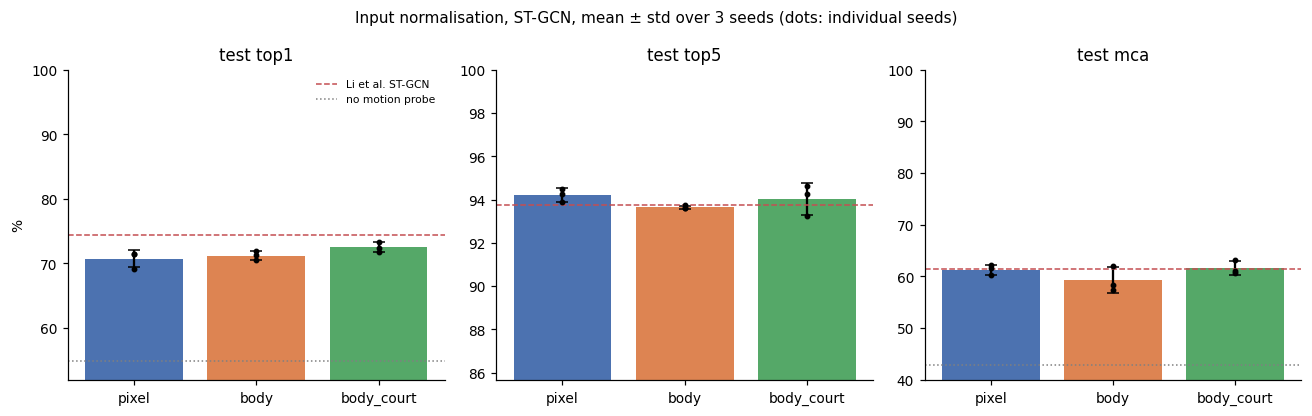

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
x = np.arange(len(CONDITIONS))
for ax, m, ref_key in zip(axes, ["test_top1", "test_top5", "test_mca"], ["top1", "top5", "mca"]):
    g = results.groupby("condition")[m]
    means, stds = g.mean().loc[list(CONDITIONS)], g.std().loc[list(CONDITIONS)]
    ax.bar(x, 100 * means, yerr=100 * stds, capsize=4, color=["#4c72b0", "#dd8452", "#55a868"])
    for i, cond in enumerate(CONDITIONS):
        ax.scatter(np.full(len(SEEDS), i), 100 * results.loc[results["condition"] == cond, m], color="black", s=8, zorder=3)
    ax.axhline(100 * LI_ET_AL_STGCN[ref_key], color="#c44e52", ls="--", lw=1, label="Li et al. ST-GCN")
    if ref_key in NO_MOTION_PROBE:
        ax.axhline(100 * NO_MOTION_PROBE[ref_key], color="grey", ls=":", lw=1, label="no motion probe")
    ax.set_xticks(x, list(CONDITIONS))
    ax.set_ylim(100 * min(means.min() - 0.08, NO_MOTION_PROBE.get(ref_key, 1) - 0.03), 100)
    ax.set_title(m.replace("test_", "test ").replace("_", " "))
axes[0].set_ylabel("%")
axes[0].legend(frameon=False, fontsize=7)
fig.suptitle(f"Input normalisation, ST-GCN, mean ± std over {len(SEEDS)} seeds (dots: individual seeds)", fontsize=10)
fig.tight_layout()
slog.report_matplotlib_figure("normalisation comparison", "test", figure=fig, iteration=0, report_interactive=False)
plt.show()

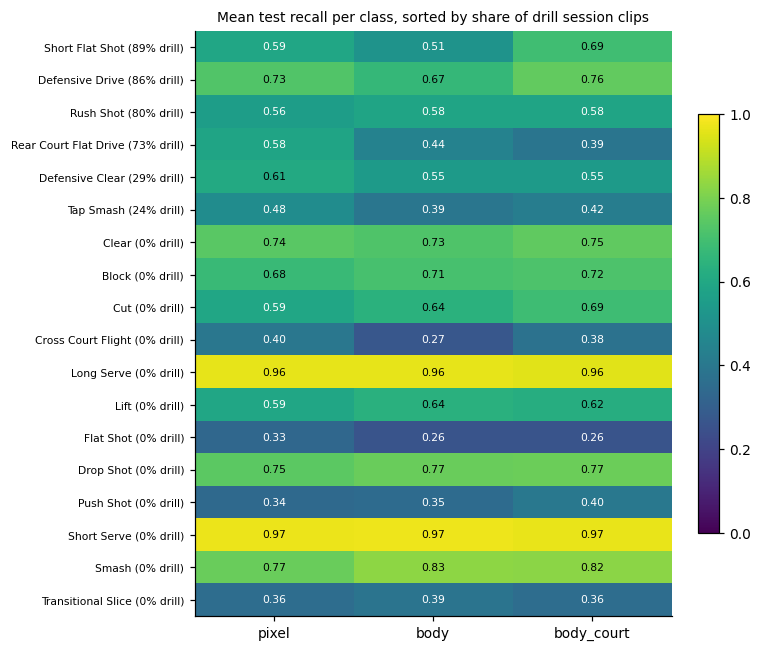

In [9]:
drill_share = manifest.assign(drill=manifest["filepath"].str.contains("2023-05-02")).groupby("class_name")["drill"].mean()
per_class = []
for _, r in results.iterrows():
    pc = pd.read_csv(f"{OUT}/{r['run']}/{r['run']}_per_class.csv")
    pc["condition"] = r["condition"]
    per_class.append(pc)
per_class = pd.concat(per_class)
recall = per_class.groupby(["class", "condition"])["recall"].mean().unstack()[list(CONDITIONS)]
recall["drill share"] = recall.index.map({c.split("_", 1)[1]: v for c, v in drill_share.items()})
recall = recall.sort_values("drill share", ascending=False).round(3)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(recall[list(CONDITIONS)].values, cmap="viridis", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(CONDITIONS)), list(CONDITIONS))
ax.set_yticks(range(len(recall)), [f"{c} ({s:.0%} drill)" for c, s in zip(recall.index, recall["drill share"])], fontsize=7)
for i in range(len(recall)):
    for j in range(len(CONDITIONS)):
        ax.text(j, i, f"{recall.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if recall.iloc[i, j] < 0.6 else "black")
ax.set_title("Mean test recall per class, sorted by share of drill session clips", fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.04)
fig.tight_layout()
slog.report_matplotlib_figure("per class recall by condition", "test", figure=fig, iteration=0, report_interactive=False)
plt.show()
slog.report_table("per class recall by condition", "test", iteration=0, table_plot=recall.reset_index())

In [10]:
rows = []
for _, r in results.iterrows():
    p = pd.read_csv(f"{OUT}/{r['run']}/{r['run']}_predictions.csv")
    p = p[p["split"] == "test"]
    p["drill"] = p["filepath"].str.contains("2023-05-02")
    p["correct"] = p["label"] == p["pred"]
    rows.append({"condition": r["condition"], "seed": r["seed"],
                 "match clips": p.loc[~p["drill"], "correct"].mean(), "drill clips": p.loc[p["drill"], "correct"].mean(),
                 "n drill": int(p["drill"].sum())})
by_source = pd.DataFrame(rows).groupby("condition")[["match clips", "drill clips", "n drill"]].mean()
by_source = by_source.loc[list(CONDITIONS)].round(4).reset_index()
slog.report_table("test accuracy, match vs drill clips", "test", iteration=0, table_plot=by_source)
summary_task.close()
by_source

,condition,match clips,drill clips,n drill
0,pixel,0.7003,0.8376,39.0
1,body,0.7097,0.7521,39.0
2,body_court,0.7187,0.8376,39.0


## Reading the result

The noise floor measured earlier for ST-GCN is about 0.85 points of top 1 and 1.3 points of mean class
accuracy between seeds, so a difference smaller than that between two conditions is not evidence either way.

- If `pixel` wins mainly through the drill dominated classes and the gap to `body` is much larger on drill clips
  than on match clips, it is relying on the camera setup rather than the stroke.
- If `body_court` recovers most of the gap, court position is a genuine cue and should be kept.
- The condition carried forward to every model is recorded in the summary task and in the thesis methods.